In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray
from ipywidgets import interact, IntSlider
from IPython.display import HTML
from scipy.stats import norm as gaussian
from matplotlib.animation import FuncAnimation
from numba import njit

In [2]:
np.random.seed(42)

# Free Path Samplng

We first consider a free particle. The hamiltonial for this system is

$$H = H^\text{free} = \frac{1}{2}\frac{\partial ^2}{\partial x^2}$$

and the densty matrix reduces to the **free density matrix**

$$\rho^\text{free}(x, x^\prime;\,\beta) = \frac{1}{\sqrt{2\pi\beta}}\;\exp\Big\{-\frac{(x - x^\prime)^2}{2\beta}\Big\}$$

In [3]:
@njit
def free_density_matrix(x: float, xp: float, beta: float) -> float:
    """
    Computes the free density matrix

    Parameters:
    -----------
    x : float
        Position for which to calculate rho_free(x, x', beta).
    xp : float
        Position for which to calculate rho_free(x, x', beta).   
    beta : float
           The inverse temperature parameter.

    Returns
    -------
    float
        The value of the free density matrix rho_free(x, xp, beta)
    """
    return np.exp(-(x - xp) ** 2 / (2 * beta)) / np.sqrt(np.pi)

Let's consider the Monte Carlo Metropolis algorithm

In [4]:
def naive_harmonic_path(x: np.ndarray, # (N, )
                        beta: float,
                        delta: float = 1,
                        n_steps: int = 1_000_000,
                       ) -> list[float]:
    """
    Generate samples of a discretized path for a quantum harmonic oscillator
    using a naive Metropolis Monte Carlo algorithm.

    Parameters
    ----------
    x : np.ndarray of shape (N,)
        Initial path configuration (positions at discretized imaginary time slices).
        This array is modified in-place during sampling.
    beta : float
        Inverse temperature (imaginary time extent).
    delta : float, optional
        Maximum magnitude of the uniform proposal displacement (default is 1).
        Proposed moves are drawn from U(-delta, delta).
    n_steps : int, optional
        Number of Metropolis updates to perform (default is 1_000_000).

    Returns
    -------
    paths : list of np.ndarray
        List of accepted path configurations. Each element is a copy of the
        path after an accepted update. The length of this list is equal to
        the number of accepted moves (not `n_steps`).
    """
    N = x.shape[0]
    Delta_t = beta / N
    paths = []
    for step in range(n_steps):
        k = np.random.randint(0, N)
        prv = (k - 1) % N
        nxt = (k + 1) % N
        dx = np.random.uniform(-delta, delta)
        pi_a = scalar_free_density_matrix(x[prv], x[k], Delta_t) \
             * scalar_free_density_matrix(x[k], x[nxt], Delta_t) \
             * np.exp(-0.5 * Delta_t * x[k] ** 2)
        pi_b = scalar_free_density_matrix(x[prv], x[k] + dx, Delta_t) \
             * scalar_free_density_matrix(x[k] + dx, x[nxt], Delta_t) \
             * np.exp(-0.5 * Delta_t * (x[k] + dx) ** 2)
        Upsilon = pi_b / pi_a if pi_a != 0 else np.float(1.0)
        if np.random.rand() < Upsilon:
            x[k] += dx
            paths.append(x.copy())
    return paths

For some fiexd $k$ the condition probability $\pi(x_k |\, x_{k-1}, x_{k+1})$ of the position $x_k$ given previous and next position $x_{k-1}, x_{k+1}$ respectively is a gaussian

$$\begin{aligned}
    \pi(x_k | x_{k-1}, x_{k+1}) &\propto
        \rho^\text{free}(x_{k-1}, x_k;\,\Delta \tau)\;\rho^\text{free}(x_k,x_{k+1};\,\Delta \tau) \\[5pt]
        &= \exp\Big\{-\frac{(x_k - \langle x_k \rangle)^2}{2\sigma^2}\Big\}
\end{aligned}$$

with mean  $\langle x_k \rangle = {\large\frac{1}{2}}(x_{k+1} - x_{k-1})$ variance $\sigma^2 = {\large\frac{\Delta \tau}{2}}$.

## Generalization

Let's consider non-uniform points $x^\prime, x_k, x^{\prime\prime}$ where the jump from $x^\prime$ to $x_k$ take imaginary time $\Delta \tau^\prime$ and the jump from $x_k$ to $x^{\prime\prime}$ take imaginary time $\Delta \tau^{\prime\prime}$. The condition probability is again a gaussian

$$\begin{aligned}
    \pi(x_k | x^\prime, x^{\prime\prime}) &\propto
        \rho^\text{free}(x^\prime, x_k;\,\Delta \tau^\prime)\;\rho^\text{free}(x_k,x^{\prime\prime};\,\Delta \tau^{\prime\prime}) \\[5pt]
        &= \exp\Big\{-\frac{(x_k - \langle x_k \rangle)^2}{2\sigma^2}\Big\}
\end{aligned}$$


where the mean value $\langle x_k \rangle$ and variance $\sigma^2$ are given by

$$\begin{aligned}
\langle x_k \rangle &= \frac{\Delta \tau^{\prime\prime}x^{\prime} + \Delta \tau^{\prime}x^{\prime}}{\Delta \tau^{\prime\prime} + \Delta \tau^{\prime}}\\ \\
\sigma^2 &= \Big( \frac{1}{\Delta \tau^{\prime\prime}} + \frac{1}{\Delta \tau^{\prime}}\Big)^{-1}
\end{aligned}$$

Thus we have the following procedure:

In [5]:
@njit
def naive_path_slice(x: float,
                     x_prime: float,
                     x_dprime: float,
                     dt_prime: float,
                     dt_dprime: float,
                     delta: float = 1.0,
                     n_steps: int = 100_000
                    ):
    """
    Perform a simple Metropolis Monte Carlo sampling of a single path slice
    in a discretized path integral.

    This function updates an intermediate position `x` connecting two fixed
    endpoints (`x_dprime` and `x_prime`) using a local random-walk proposal.
    The acceptance probability is computed from the product of free-particle
    density matrices connecting neighboring time slices.

    Parameters
    ----------
    x : float
        Initial value of the intermediate path slice to be sampled.
    x_prime : float
        Fixed endpoint at the forward time slice.
    x_dprime : float
        Fixed endpoint at the backward time slice.
    dt_prime : float
        Imaginary-time step between `x` and `x_prime`.
    dt_dprime : float
        Imaginary-time step between `x` and `x_dprime`.
    delta : float, optional
        Maximum magnitude of proposed uniform random displacement
        (default is 1.0). Proposals are drawn from U(-delta, delta).
    n_steps : int, optional
        Number of Metropolis updates to perform (default is 100).

    Returns
    -------
    values : list of float
        Sequence of sampled values of the intermediate slice `x`
        over the Monte Carlo trajectory, including both accepted
        and rejected states.
    """
    values = [x]
    for step in range(n_steps):
        dx = np.random.uniform(-delta, delta)
        old_weight = (free_density_matrix(x_dprime, x, dt_dprime) *
                      free_density_matrix(x, x_prime, dt_dprime))
        new_weight = (free_density_matrix(x_dprime, x + dx, dt_dprime) *
                      free_density_matrix(x + dx, x_prime, dt_prime))
        if np.random.rand() < new_weight / old_weight:
            x += dx
        values.append(x)
    return values

+----------------------------------------------+
| Estimated mean = 0.6663 | True mean = 0.6667 |
| Estimated  std = 0.2596 | True std  = 0.2582 |
+----------------------------------------------+


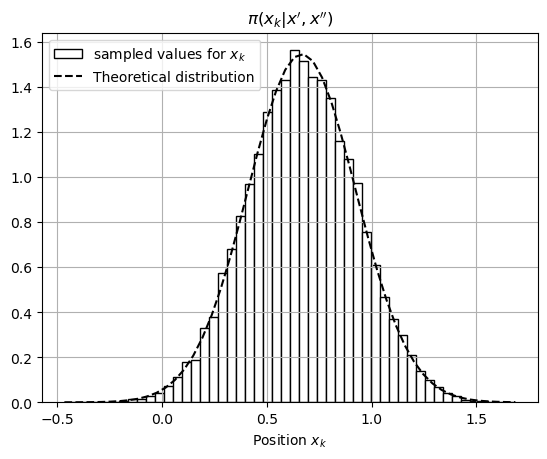

In [9]:
# Set up parametes
n_steps = 100_000
x = 0.0
x_dprime = 0.0
x_prime = 1.0
dt_dprime = 0.2
dt_prime = 0.1

# Sample points
x_values = naive_path_slice(x, 
                            x_prime, x_dprime,
                            dt_prime, dt_dprime,
                            n_steps=n_steps)

# Compute distrivution parameters
mean = (x_prime * dt_dprime + x_dprime * dt_prime) / (dt_prime + dt_dprime)
std = np.sqrt(1 / ((1 / dt_prime) + (1 / dt_dprime)))
xspan = np.linspace(min(x_values), max(x_values))
pi_theo = gaussian.pdf(xspan, loc=mean, scale=std)

# Print estimated values
print('+----------------------------------------------+')
print(f"| Estimated mean = {np.mean(x_values):.4f} | True mean = {mean:.4f} |")
print(f"| Estimated  std = {np.std(x_values):.4f} | True std  = {std:.4f} |")
print('+----------------------------------------------+')

plt.hist(x_values, bins=50, density=True,
         color='white', edgecolor='black',
         label=r'sampled values for $x_k$')
plt.plot(xspan, pi_theo, '--', color='black',
         label='Theoretical distribution')
plt.grid()
plt.xlabel(r'Position $x_k$')
plt.legend()
plt.title(r'$\pi(x_k | x^\prime, x^{\prime\prime})$')
plt.show()